Avvio il fitting...
Fit completato con successo!
Gamma1   = 532.1186
Gamma2   = 1022.7149
phi_star = 0.5242 rad (30.04 gradi)
w0       = 4.1741


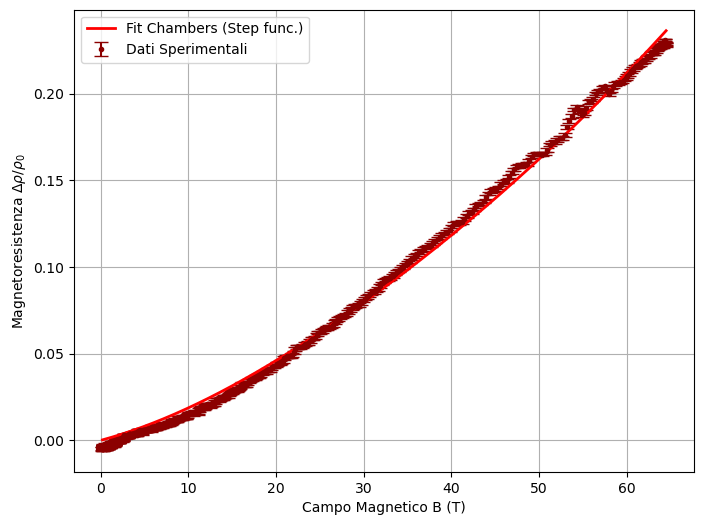

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sigma_xx(B, Gamma1, Gamma2, phi_star, w0):
    """
    Calcola la conduttività sigma_xx per un dato campo magnetico B
    secondo il modello di Chambers a gradino.
    """
    A = 1.0 # Si semplificherà nel rapporto sigma_0 / sigma_xx
    psi_star = np.pi/4 - phi_star
    
    # Frequenza ciclotronica
    w = w0 * B
    
    # Evitiamo divisioni per zero forzando w a un valore trascurabile quando B=0
    w = np.where(w == 0, 1e-12, w)
    
    # Tempi di volo
    S1 = 2 * psi_star / w
    S2 = 2 * phi_star / w
    
    # Denominatore in comune
    denom = 1 + 1j * np.exp(-(Gamma1 * S2 + Gamma2 * S1))
    
    # Calcolo Z12
    diff_G2_G1 = 1 / (Gamma2 + 1j*w) - 1 / (Gamma1 + 1j*w)
    Z12 = (1 - np.exp(-(Gamma2 + 1j*w)*S1)) / denom * diff_G2_G1
    
    # Calcolo Z21
    diff_G1_G2 = 1 / (Gamma1 + 1j*w) - 1 / (Gamma2 + 1j*w)
    Z21 = (1 - np.exp(-(Gamma1 + 1j*w)*S2)) / denom * diff_G1_G2
    
    # Semplificazione del termine sinh 
    term1 = (1 - np.exp(-(Gamma1 + 1j*w)*S2)) / 2.0
    term2 = (1 - np.exp(-(Gamma2 + 1j*w)*S1)) / 2.0
    
    # Componenti O_I1 e O_I2
    O_I1 = (4 * A / (Gamma1**2 + w**2)) * (Gamma1 - 1j*w) * (phi_star + Z12 * w * term1)
    O_I2 = (4 * A / (Gamma2**2 + w**2)) * (Gamma2 - 1j*w) * (psi_star + Z21 * w * term2)
    
    # La conduttività diagonale è la somma delle parti reali
    sig_xx = np.real(O_I1) + np.real(O_I2)
    return sig_xx

def mr_model(B, Gamma1, Gamma2, phi_star, w0):
    """
    Calcola la Magnetoresistenza MR = sigma(0) / sigma_xx(B) - 1
    """
    # Valutiamo sigma in B->0 per approssimare sigma_0
    sigma_0_val = sigma_xx(np.array([1e-8]), Gamma1, Gamma2, phi_star, w0)[0]
    
    sig_xx_val = sigma_xx(B, Gamma1, Gamma2, phi_star, w0)
    
    # Calcolo magnetoresistenza
    MR = (sigma_0_val / sig_xx_val) - 1.0
    return MR

# ==========================================
# LETTURA DATI E FITTING
# ==========================================

# Leggiamo il file saltando le righe di header
columns_names = ['B_S1', 'rho_ratio_S1', 'B_S2', 'rho_ratio_S2', 'B_Nd', 'rho_ratio_Nd']
df = pd.read_csv('41567_2022_1763_MOESM6_ESM.txt', sep='\s+', skiprows=2, names=columns_names)

# Selezioniamo SOLO le colonne di S1 (a 30K) e rimuoviamo i NaN specifici per questo campione
df_S1 = df[['B_S1', 'rho_ratio_S1']].dropna()

B_data = df_S1['B_S1'].values.astype(float)
rho_ratio_data = df_S1['rho_ratio_S1'].values.astype(float)

# Variabile dipendente da fittare (MR)
MR_data = rho_ratio_data - 1.0

# Initial guesses per [Gamma1, Gamma2, phi_star, w0]
p0 = [10.0, 20.0, np.pi/8, 5]

# Bounds: Gamma > 0, phi_star in [0, pi/4], w0 > 0
bounds = ([0.01, 0.01, 0.0, 0.01], [np.inf, np.inf, np.pi/4, np.inf])

print("Avvio il fitting...")
popt, pcov = curve_fit(mr_model, B_data, MR_data, p0=p0, bounds=bounds, maxfev=5000)

print("Fit completato con successo!")
print(f"Gamma1   = {popt[0]:.4f}")
print(f"Gamma2   = {popt[1]:.4f}")
print(f"phi_star = {popt[2]:.4f} rad ({np.degrees(popt[2]):.2f} gradi)")
print(f"w0       = {popt[3]:.4f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.errorbar(B_data[::10], MR_data[::10],yerr= np.repeat(0.001,len(B_data))[::10], fmt='.',capsize = 5, color = 'darkred', label="Dati Sperimentali")

B_fit = np.linspace(B_data.min(), B_data.max(), 500)
MR_fit = mr_model(B_fit, *popt)

plt.plot(B_fit, MR_fit, color='red', linewidth=2, label="Fit Chambers (Step func.)")
plt.xlabel('Campo Magnetico B (T)')
plt.ylabel(r'Magnetoresistenza $\Delta\rho/\rho_0$')
plt.legend()
plt.grid(True)
plt.show()

--- Parametri per LSCO S1 ---
Gamma1   = 60.3807
Gamma2   = 116.0529
phi_star = 0.5243 rad (30.0°)
w0       = 0.4736

--- Parametri per LSCO S2 ---
Gamma1   = 111.7331
Gamma2   = 182.4659
phi_star = 0.4288 rad (24.6°)
w0       = 0.4376

--- Parametri per Nd-LSCO ---
Gamma1   = 91.9547
Gamma2   = 159.7970
phi_star = 0.4993 rad (28.6°)
w0       = 0.4490



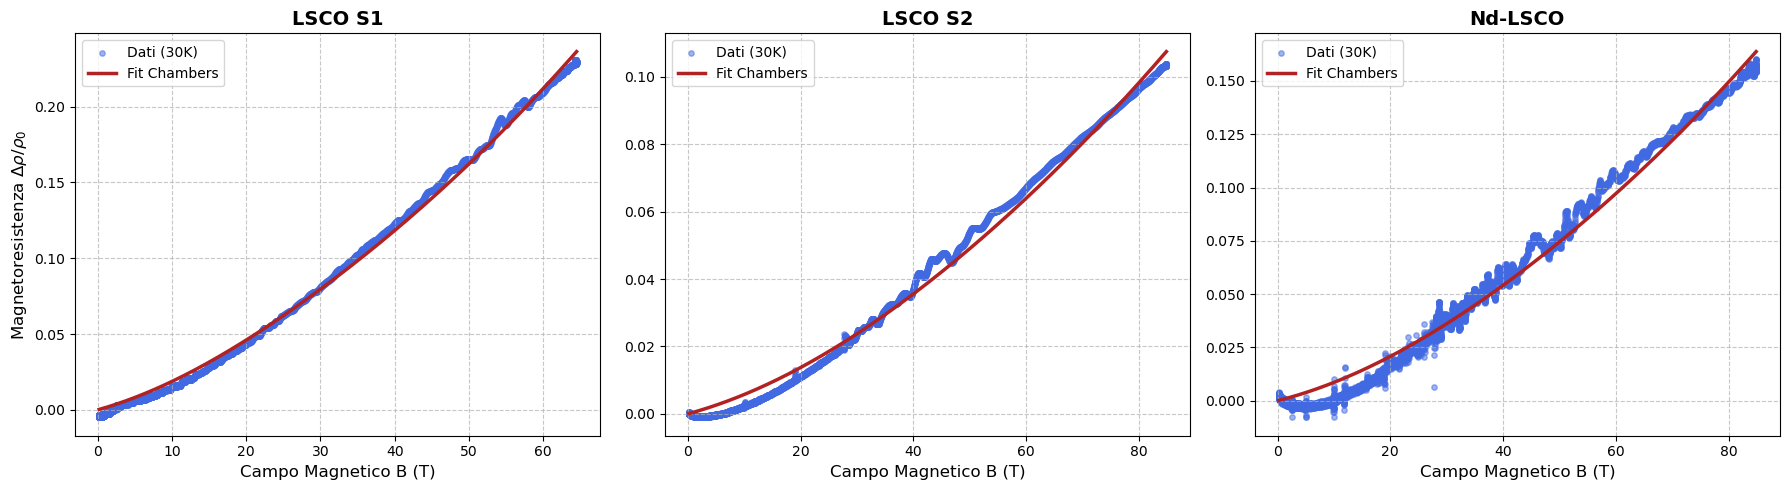

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sigma_xx(B, Gamma1, Gamma2, phi_star, w0):
    """
    Calcola la conduttività sigma_xx per un dato campo magnetico B
    secondo il modello di Chambers a gradino.
    """
    A = 1.0
    psi_star = np.pi/4 - phi_star
    w = w0 * B
    
    # Previene divisioni per zero
    w = np.where(w == 0, 1e-12, w)
    
    S1 = 2 * psi_star / w
    S2 = 2 * phi_star / w
    
    denom = 1 + 1j * np.exp(-(Gamma1 * S2 + Gamma2 * S1))
    
    diff_G2_G1 = 1 / (Gamma2 + 1j*w) - 1 / (Gamma1 + 1j*w)
    Z12 = (1 - np.exp(-(Gamma2 + 1j*w)*S1)) / denom * diff_G2_G1
    
    diff_G1_G2 = 1 / (Gamma1 + 1j*w) - 1 / (Gamma2 + 1j*w)
    Z21 = (1 - np.exp(-(Gamma1 + 1j*w)*S2)) / denom * diff_G1_G2
    
    term1 = (1 - np.exp(-(Gamma1 + 1j*w)*S2)) / 2.0
    term2 = (1 - np.exp(-(Gamma2 + 1j*w)*S1)) / 2.0
    
    O_I1 = (4 * A / (Gamma1**2 + w**2)) * (Gamma1 - 1j*w) * (phi_star + Z12 * w * term1)
    O_I2 = (4 * A / (Gamma2**2 + w**2)) * (Gamma2 - 1j*w) * (psi_star + Z21 * w * term2)
    
    sig_xx = np.real(O_I1) + np.real(O_I2)
    return sig_xx

def mr_model(B, Gamma1, Gamma2, phi_star, w0):
    """
    Calcola la Magnetoresistenza MR = sigma(0) / sigma_xx(B) - 1
    """
    sigma_0_val = sigma_xx(np.array([1e-8]), Gamma1, Gamma2, phi_star, w0)[0]
    sig_xx_val = sigma_xx(B, Gamma1, Gamma2, phi_star, w0)
    MR = (sigma_0_val / sig_xx_val) - 1.0
    return MR

# ==========================================
# 1. LETTURA DATI
# ==========================================
columns_names = ['B_S1', 'rho_ratio_S1', 'B_S2', 'rho_ratio_S2', 'B_Nd', 'rho_ratio_Nd']
df = pd.read_csv('41567_2022_1763_MOESM6_ESM.txt', sep='\s+', skiprows=2, names=columns_names)

# Definiamo i campioni da ciclare
campioni = [
    {'titolo': 'LSCO S1', 'col_B': 'B_S1', 'col_rho': 'rho_ratio_S1'},
    {'titolo': 'LSCO S2', 'col_B': 'B_S2', 'col_rho': 'rho_ratio_S2'},
    {'titolo': 'Nd-LSCO', 'col_B': 'B_Nd', 'col_rho': 'rho_ratio_Nd'}
]

# Impostazioni di Fit
p0 = [1.0, 5.0, np.pi/8, 0.5]
bounds = ([0.01, 0.01, 0.0, 0.01], [np.inf, np.inf, np.pi/4, np.inf])

# ==========================================
# 2. PLOT E FITTING AUTOMATICO
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, info in enumerate(campioni):
    # Estraiamo e puliamo solo le colonne di questo specifico campione
    df_temp = df[[info['col_B'], info['col_rho']]].dropna()
    
    B_data = df_temp[info['col_B']].values.astype(float)
    MR_data = df_temp[info['col_rho']].values.astype(float) - 1.0
    
    # Plot dati sperimentali
    axs[i].scatter(B_data, MR_data, s=15, color='royalblue', alpha=0.5, label='Dati (30K)')
    
    # Eseguiamo il fit
    try:
        popt, pcov = curve_fit(mr_model, B_data, MR_data, p0=p0, bounds=bounds, maxfev=5000)
        
        # Generiamo la curva di fit
        B_fit = np.linspace(B_data.min(), B_data.max(), 500)
        MR_fit = mr_model(B_fit, *popt)
        
        # Plot curva di fit
        axs[i].plot(B_fit, MR_fit, color='firebrick', linewidth=2.5, label='Fit Chambers')
        
        # Stampa dei parametri trovati
        print(f"--- Parametri per {info['titolo']} ---")
        print(f"Gamma1   = {popt[0]:.4f}")
        print(f"Gamma2   = {popt[1]:.4f}")
        print(f"phi_star = {popt[2]:.4f} rad ({np.degrees(popt[2]):.1f}°)")
        print(f"w0       = {popt[3]:.4f}\n")
        
    except Exception as e:
        print(f"Attenzione: Fit fallito per {info['titolo']} -> {e}")
    
    # Formattazione del singolo pannello
    axs[i].set_title(info['titolo'], fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Campo Magnetico B (T)', fontsize=12)
    if i == 0:
        axs[i].set_ylabel(r'Magnetoresistenza $\Delta\rho/\rho_0$', fontsize=12)
    
    axs[i].grid(True, linestyle='--', alpha=0.7)
    axs[i].legend()

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import iv
from tqdm import tqdm  # <-- Importiamo la libreria per la barra di caricamento!

def calc_cN(t, alpha, N, mu_max=15):
    """Calcola il coefficiente c_N(t) sommando su mu."""
    c_N = np.zeros_like(alpha, dtype=float)
    for mu in range(-mu_max, mu_max + 1):
        segno_mu = (-1.0)**mu
        bessel_1 = iv(t - 2*mu, alpha)
        bessel_2 = iv(mu, alpha / 8.0)
        bessel_3 = iv(t - 2*(mu - N), alpha)
        bessel_4 = iv(mu - N, alpha / 8.0)
        c_N += segno_mu * bessel_1 * bessel_2 * bessel_3 * bessel_4
    return c_N

def sigma_xx_bessel(B, Gamma_tilde, Gamma_an, w0):
    """Calcola la conduttività diagonale."""
    w = w0 * B
    w = np.where(w < 1e-6, 1e-6, w) 
    
    alpha_raw = Gamma_an / (8.0 * w)
    alpha = np.clip(alpha_raw, a_min=-150.0, a_max=150.0)
    
    sigma_val = np.zeros_like(B, dtype=float)
    t_max = 15
    
    for t in range(-t_max, t_max + 1):
        segno_t = (-1.0)**t
        t_an = 4.0 * t + 1.0
        
        c0 = calc_cN(t, alpha, N=0)
        c1 = calc_cN(t, alpha, N=1)
        
        num = Gamma_tilde * c0 - w * t_an * c1
        den = Gamma_tilde**2 + (w * t_an)**2
        
        sigma_val += segno_t * (num / den)
        
    return np.pi * sigma_val

def mr_model_bessel(B, Gamma_tilde, Gamma_an, w0):
    """Calcola la Magnetoresistenza teorica."""
    eff_gamma_sq = np.maximum(Gamma_tilde**2 - Gamma_an**2, 1e-12)
    sigma_0_val = np.pi / np.sqrt(eff_gamma_sq)
    
    sig_xx_val = sigma_xx_bessel(B, Gamma_tilde, Gamma_an, w0)
    return (sigma_0_val / sig_xx_val) - 1.0

# ==========================================
# 1. LETTURA DATI
# ==========================================
columns_names = ['B_S1', 'rho_ratio_S1', 'B_S2', 'rho_ratio_S2', 'B_Nd', 'rho_ratio_Nd']
df = pd.read_csv('41567_2022_1763_MOESM6_ESM.txt', sep='\s+', skiprows=2, names=columns_names)

df_S1 = df[['B_S1', 'rho_ratio_S1']].dropna()
B_data = df_S1['B_S1'].values.astype(float)
MR_data = df_S1['rho_ratio_S1'].values.astype(float) - 1.0

# ==========================================
# 2. FITTING CON PROGRESS BAR
# ==========================================
p0 = [2.0, 1.0, 0.5]
bounds = ([0.01, 0.0, 0.01], [np.inf, np.inf, np.inf])
max_evaluations = 2000

print("Inizializzazione modello... avvio del fitting di Bessel.")

# Creiamo la barra di caricamento
pbar = tqdm(total=max_evaluations, desc="Ottimizzazione parametri", unit="iter")

def mr_model_bessel_with_pbar(B, Gamma_tilde, Gamma_an, w0):
    """Questa funzione avvolge il modello reale aggiornando la barra ad ogni chiamata."""
    pbar.update(1)
    return mr_model_bessel(B, Gamma_tilde, Gamma_an, w0)

try:
    # Eseguiamo il fit usando la funzione avvolta con la barra
    popt, pcov = curve_fit(mr_model_bessel_with_pbar, B_data, MR_data, p0=p0, bounds=bounds, maxfev=max_evaluations)
    pbar.close() # Chiudiamo la barra
    
    print("\nFit completato con successo!")
    print(f"Gamma_tilde (isotropo)   = {popt[0]:.4f}")
    print(f"Gamma_an    (anisotropo) = {popt[1]:.4f}")
    print(f"w0                       = {popt[2]:.4f}")
    
    # Calcolo della curva di fit per il grafico
    print("\nGenerazione del grafico in corso...")
    plt.figure(figsize=(8, 6))
    plt.scatter(B_data, MR_data, s=10, color='royalblue', alpha=0.5, label='LSCO S1 (30K)')
    
    B_fit = np.linspace(B_data.min(), B_data.max(), 500)
    # Per il plot usiamo la funzione originale (senza barra, che ormai è chiusa)
    MR_fit = mr_model_bessel(B_fit, *popt)
    
    plt.plot(B_fit, MR_fit, color='darkorange', linewidth=2.5, label='Fit Chambers (Bessel)')
    plt.xlabel('Campo Magnetico B (T)', fontsize=12)
    plt.ylabel(r'Magnetoresistenza $\Delta\rho/\rho_0$', fontsize=12)
    plt.title('Fit Modello Scattering Armonico ($\\nu=4$)', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    pbar.close()
    print(f"\nErrore durante il fitting: {e}")

Inizializzazione modello... avvio del fitting di Bessel.


Ottimizzazione parametri:   2%|▊                                                 | 31/2000 [03:23<3:43:17,  6.80s/iter]

KeyboardInterrupt: 

Inizializzazione modello... avvio del fitting di Bessel.



Ottimizzazione parametri:   2%|▊                                                 | 32/2000 [08:10<8:22:28, 15.32s/iter]

Ottimizzazione parametri:   6%|██▉                                                 | 85/1500 [00:40<11:14,  2.10iter/s]



Fit completato con successo!
Gamma_tilde (isotropo)   = 53.9793
Gamma_an    (anisotropo) = 5.4627
w0                       = 0.4187


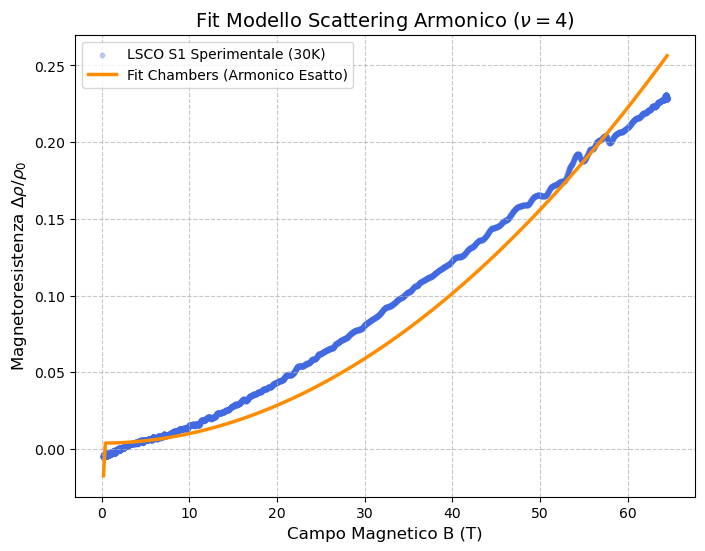

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import iv
from tqdm import tqdm  # <-- Importazione della barra di caricamento

def calc_cN(t, alpha, N, mu_max=12):
    """Calcola il coefficiente c_N(t) in modo vettorizzato."""
    c_N = np.zeros_like(alpha, dtype=float)
    for mu in range(-mu_max, mu_max + 1):
        segno_mu = (-1.0)**mu
        bessel_1 = iv(t - 2*mu, alpha)
        bessel_2 = iv(mu, alpha / 8.0)
        bessel_3 = iv(t - 2*(mu - N), alpha)
        bessel_4 = iv(mu - N, alpha / 8.0)
        c_N += segno_mu * bessel_1 * bessel_2 * bessel_3 * bessel_4
    return c_N

def sigma_xx_bessel(B, Gamma_tilde, Gamma_an, w0):
    """Conduttività esatta Modello Armonico."""
    w = w0 * B
    w = np.where(w < 1e-6, 1e-6, w) 
    
    # Cap di sicurezza per evitare overflow numerico
    alpha_raw = Gamma_an / (8.0 * w)
    alpha = np.clip(alpha_raw, a_min=-100.0, a_max=100.0)
    
    sigma_val = np.zeros_like(B, dtype=float)
    t_max = 12
    
    for t in range(-t_max, t_max + 1):
        segno_t = (-1.0)**t
        t_an = 4.0 * t + 1.0
        
        c0 = calc_cN(t, alpha, N=0)
        c1 = calc_cN(t, alpha, N=1)
        
        num = Gamma_tilde * c0 - w * t_an * c1
        den = Gamma_tilde**2 + (w * t_an)**2
        
        sigma_val += segno_t * (num / den)
        
    return np.pi * sigma_val

def mr_model_bessel(B, Gamma_tilde, Gamma_an, w0):
    """Magnetoresistenza con limite analitico esatto a B=0."""
    # B=0 bypassa le Bessel usando il limite analitico esatto
    eff_gamma_sq = np.maximum(Gamma_tilde**2 - Gamma_an**2, 1e-12)
    sigma_0_val = np.pi / np.sqrt(eff_gamma_sq)
    
    sig_xx_val = sigma_xx_bessel(B, Gamma_tilde, Gamma_an, w0)
    return (sigma_0_val / sig_xx_val) - 1.0

# ==========================================
# 1. LETTURA DATI
# ==========================================
columns_names = ['B_S1', 'rho_ratio_S1', 'B_S2', 'rho_ratio_S2', 'B_Nd', 'rho_ratio_Nd']
df = pd.read_csv('41567_2022_1763_MOESM6_ESM.txt', sep='\s+', skiprows=2, names=columns_names)

df_S1 = df[['B_S1', 'rho_ratio_S1']].dropna()
B_data = df_S1['B_S1'].values.astype(float)
MR_data = df_S1['rho_ratio_S1'].values.astype(float) - 1.0

# TRUCCO DI VELOCITÀ: fittiamo su un subset dei dati (1 punto ogni 10)
B_fit_subset = B_data[::10]
MR_fit_subset = MR_data[::10]

# ==========================================
# 2. FITTING CON PROGRESS BAR
# ==========================================
p0 = [2.0, 1.0, 0.5]
bounds = ([0.01, 0.0, 0.01], [np.inf, np.inf, np.inf])
max_evaluations = 1500

print("Inizializzazione modello... avvio del fitting di Bessel.")

# Inizializziamo la barra di caricamento
pbar = tqdm(total=max_evaluations, desc="Ottimizzazione parametri", unit="iter")

def mr_model_bessel_con_barra(B, Gamma_tilde, Gamma_an, w0):
    """Funzione 'wrapper' per aggiornare la barra ad ogni tentativo del fit."""
    pbar.update(1)
    return mr_model_bessel(B, Gamma_tilde, Gamma_an, w0)

try:
    # Passiamo la funzione con la barra al curve_fit
    popt, pcov = curve_fit(mr_model_bessel_con_barra, B_fit_subset, MR_fit_subset, p0=p0, bounds=bounds, maxfev=max_evaluations)
    pbar.close() # Chiude correttamente la barra quando finisce
    
    print("\nFit completato con successo!")
    print(f"Gamma_tilde (isotropo)   = {popt[0]:.4f}")
    print(f"Gamma_an    (anisotropo) = {popt[1]:.4f}")
    print(f"w0                       = {popt[2]:.4f}")
    
    plt.figure(figsize=(8, 6))
    # Plottiamo tutti i dati originali in trasparenza
    plt.scatter(B_data, MR_data, s=10, color='royalblue', alpha=0.3, label='LSCO S1 Sperimentale (30K)')
    
    B_line = np.linspace(B_data.min(), B_data.max(), 300)
    # Per disegnare la linea finale usiamo la funzione originale (senza barra)
    MR_line = mr_model_bessel(B_line, *popt)
    
    plt.plot(B_line, MR_line, color='darkorange', linewidth=2.5, label='Fit Chambers (Armonico Esatto)')
    plt.xlabel('Campo Magnetico B (T)', fontsize=12)
    plt.ylabel(r'Magnetoresistenza $\Delta\rho/\rho_0$', fontsize=12)
    plt.title('Fit Modello Scattering Armonico ($\\nu=4$)', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

except Exception as e:
    pbar.close()
    print(f"\nErrore durante il fitting: {e}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import iv

def calc_cN_normalized(t, alpha, N, mu_max=15):
    """Calcola il coefficiente c_N(t) normalizzato."""
    c_N = np.zeros_like(alpha, dtype=float)
    for mu in range(-mu_max, mu_max + 1):
        segno_mu = (-1.0)**mu
        bessel_1 = iv(t - 2*mu, alpha)
        bessel_2 = iv(mu, alpha / 8.0)
        bessel_3 = iv(t - 2*(mu - N), alpha)
        bessel_4 = iv(mu - N, alpha / 8.0)
        c_N += segno_mu * bessel_1 * bessel_2 * bessel_3 * bessel_4
    return c_N

def sigma_xx_normalized(x, gamma_ratio):
    """Calcola la conduttività con le variabili adimensionali della tabella."""
    x = np.where(x < 1e-6, 1e-6, x)
    
    # alpha = (Gamma_an / Gamma_tilde) / (8 * x)
    alpha = gamma_ratio / (8.0 * x)
    alpha = np.clip(alpha, -150.0, 150.0)
    
    sigma_val = np.zeros_like(x, dtype=float)
    t_max = 15
    
    for t in range(-t_max, t_max+1):
        segno_t = (-1.0)**t
        t_an = 4.0 * t + 1.0
        
        c0 = calc_cN_normalized(t, alpha, N=0)
        c1 = calc_cN_normalized(t, alpha, N=1)
        
        # Tutto normalizzato: Gamma_tilde diventa 1.0, omega diventa x
        num = c0 - x * t_an * c1
        den = 1.0 + (x * t_an)**2
        sigma_val += segno_t * (num / den)
        
    return sigma_val

def mr_model_normalized(B, mu, gamma_ratio):
    """Calcola la MR usando x = mu * B."""
    x = mu * B
    sig_0 = 1.0 / np.sqrt(1.0 - gamma_ratio**2) # Limite analitico normalizzato
    sig_xx = sigma_xx_normalized(x, gamma_ratio)
    return (sig_0 / sig_xx) - 1.0

# ==========================================
# 1. LETTURA DATI
# ==========================================
columns_names = ['B_S1', 'rho_ratio_S1', 'B_S2', 'rho_ratio_S2', 'B_Nd', 'rho_ratio_Nd']
df = pd.read_csv('41567_2022_1763_MOESM6_ESM.txt', sep='\s+', skiprows=2, names=columns_names)

# Funzione per estrarre la MR (rho(B)/rho(0) - 1)
def estrai_mr(col_B, col_rho):
    temp = df[[col_B, col_rho]].dropna()
    return temp[col_B].values.astype(float), temp[col_rho].values.astype(float) - 1.0

B_S1, MR_S1 = estrai_mr('B_S1', 'rho_ratio_S1')
B_S2, MR_S2 = estrai_mr('B_S2', 'rho_ratio_S2')
B_Nd, MR_Nd = estrai_mr('B_Nd', 'rho_ratio_Nd')

# ==========================================
# 2. PARAMETRI ESTRATTI DALLA TABELLA
# ==========================================
# LSCO S1: omega_c*tau @ 80T = 0.26  |  Anisotropia = 6%
mu_S1 = 0.26 / 80.0
g_ratio_S1 = 0.06

# LSCO S2: omega_c*tau @ 80T = 0.075 |  Anisotropia = 6%
mu_S2 = 0.075 / 80.0
g_ratio_S2 = 0.06

# Nd-LSCO: omega_c*tau @ 80T = 0.16  |  Anisotropia = 18%
mu_Nd = 0.16 / 80.0
g_ratio_Nd = 0.18

# ==========================================
# 3. CREAZIONE GRAFICO COMPLETO
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

campioni = [
    (axs[0], B_S1, MR_S1, mu_S1, g_ratio_S1, 'LSCO S1'),
    (axs[1], B_S2, MR_S2, mu_S2, g_ratio_S2, 'LSCO S2'),
    (axs[2], B_Nd, MR_Nd, mu_Nd, g_ratio_Nd, 'Nd-LSCO')
]

for ax, B, MR_exp, mu, g_ratio, titolo in campioni:
    # Plot sperimentale
    ax.scatter(B, MR_exp, s=15, color='royalblue', alpha=0.5, label=f'Dati ({titolo})')
    
    # Valutazione del modello coi parametri fissi della tabella
    MR_teorica = mr_model_normalized(B, mu, g_ratio)
    ax.plot(B, MR_teorica, color='firebrick', linewidth=2.5, label='Formula di Chambers (Bessel)')
    
    # Estetica
    ax.set_title(f'{titolo}\n$(\omega_c\\tilde{{\\tau}})_{{80T}}={mu*80:.3f}$, $\\Gamma_{{an}}/\\tilde{{\\Gamma}}={g_ratio*100:.0f}\%$', fontsize=12)
    ax.set_xlabel('Campo Magnetico B (T)', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

axs[0].set_ylabel(r'Magnetoresistenza $\Delta\rho/\rho_0$', fontsize=12)
plt.tight_layout()
plt.show()

Campione selezionato: LSCO S1
Punti caricati dal file: 338
  Magnetoresistance fit — Nd-LSCO p=24%, T=30K
  FS circolare, Γ(φ) = Γ_is + Γ_an·|cos(2φ)|⁴

  Fit Nelder-Mead in corso...

  Fit completato in 294.6s (206 iter)                                                  

  ┌──────────────────────────────────────────────┐
  │           RISULTATI  FIT  (ν = 4)              │
  ├──────────────────────────────────────────────┤
  │  Γ_is          =   37.200 meV                │
  │  Γ_an          =   35.377 meV                │
  │  m*            =   0.6756 eV⁻¹                │
  │                =    0.345 mₑ                  │
  │  Γ̃ = Γ_is+c₀Γ_an = 50.467 meV          │
  │  B*            =     31.1 T                  │
  │  RMS           = 0.00766                     │
  │  Converged     : True                       │
  └──────────────────────────────────────────────┘

    B(T)    MR_exp    MR_fit     residuo
       0   -0.0050    0.0060    -0.01095
       0   -0.0036    0.0060    -0

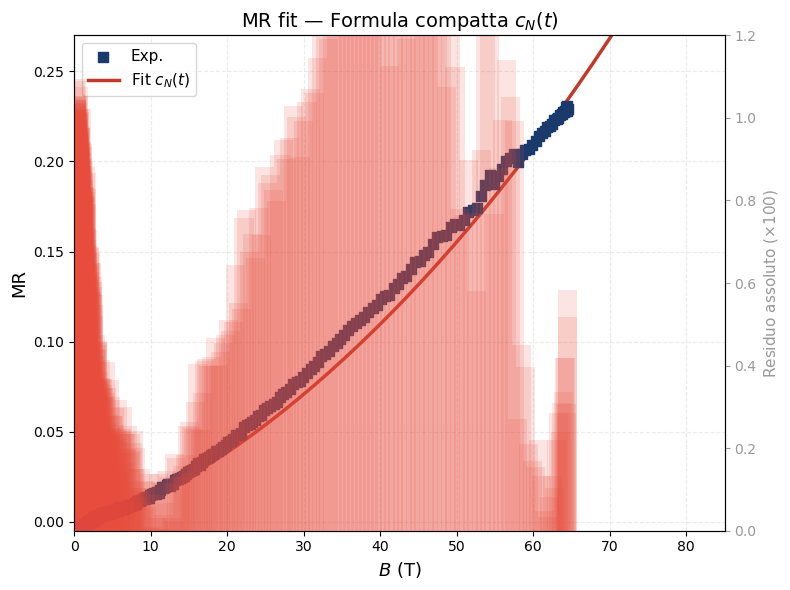


  Done.


In [1]:
"""
Magnetoresistance fit — Nd-LSCO p=24%, T=30K
=============================================
FS circolare, Γ(φ) = Γ_is + Γ_an·|cos(2φ)|^ν   con ν = 4

Metodo: integrale di Chambers numerico (vectorizzato).

σ_xx = (1/2π) ∫₀²π dφ · cos(φ) · ∫₀∞ dt · cos(φ−ωt) · exp(−∫₀ᵗ Γ(φ−ωs) ds)

Dati sperimentali: Ataei et al. / Mirarchi & Caprara 2024, fino a ~80 T.

Opzionalmente confronta con la formula analitica GBF a 4 somme (VERIFY = True).
"""

import sys
import time
import numpy as np
from scipy.optimize import minimize
from scipy.special import iv
import matplotlib.pyplot as plt
from math import comb
import pandas as pd

# ═══════════════════════════════════════════════════════════════
# OPZIONI
# ═══════════════════════════════════════════════════════════════
VERIFY  = False    # confronto Chambers vs formula analitica GBF
N_PHI   = 120      # punti griglia angolare (per plot finale)
N_T     = 1500     # punti griglia temporale (per plot finale)
                   # Per il fit: 80/800 (veloce); per il plot: 120/1500 (preciso)

# ═══════════════════════════════════════════════════════════════
# COSTANTI
# ═══════════════════════════════════════════════════════════════
HBAR = 1.0546e-34
E_C  = 1.602e-19
A_0  = 3.8e-10
B0   = HBAR / (E_C * A_0**2)    # ≈ 4560 T  (ℏ/(e·a²))

NU = 4
C0 = comb(NU, NU//2)     / 2**NU   # 3/8
C1 = 2*comb(NU, NU//2-1) / 2**NU   # 1/2
C2 = 2*comb(NU, NU//2-2) / 2**NU   # 1/8

# ═══════════════════════════════════════════════════════════════
# DATI SPERIMENTALI  (Nd-LSCO p=0.24, T=30 K)
# ═══════════════════════════════════════════════════════════════
#B_EXP = np.array([5, 10, 15, 20, 25, 30, 35, 40,
 #                 45, 50, 55, 60, 65, 70, 75, 80], dtype=float)
#MR_EXP = np.array([0.005, 0.013, 0.022, 0.032, 0.044, 0.057, 0.071, 0.085,
 #                  0.100, 0.115, 0.131, 0.147, 0.163, 0.180, 0.196, 0.213])

columns_names = ['B_S1', 'rho_ratio_S1', 'B_S2', 'rho_ratio_S2', 'B_Nd', 'rho_ratio_Nd']
df = pd.read_csv('41567_2022_1763_MOESM6_ESM.txt', sep='\s+', skiprows=2, names=columns_names)

# Definiamo la struttura delle colonne
campioni = [
    {'nome': 'LSCO S1', 'B': 'B_S1', 'rho': 'rho_ratio_S1'},
    {'nome': 'LSCO S2', 'B': 'B_S2', 'rho': 'rho_ratio_S2'},
    {'nome': 'Nd-LSCO', 'B': 'B_Nd', 'rho': 'rho_ratio_Nd'}
]

# ==========================================
# SCEGLI QUI L'INDICE DEL CAMPIONE (0, 1 o 2)
# 0 -> LSCO S1
# 1 -> LSCO S2
# 2 -> Nd-LSCO
# ==========================================
l = 0 

# Estrazione dei dati in base all'indice scelto
col_B = campioni[l]['B']
col_rho = campioni[l]['rho']
nome_campione = campioni[l]['nome']

df_selezionato = df[[col_B, col_rho]].dropna()

# Dati estratti dal file pronti per il fit
B_File = df_selezionato[col_B].values.astype(float)
MR_File = df_selezionato[col_rho].values.astype(float) - 1.0

B_EXP = B_File[::20]
MR_EXP = MR_File[::20]

print(f"Campione selezionato: {nome_campione}")
print(f"Punti caricati dal file: {len(B_EXP)}")
# ═══════════════════════════════════════════════════════════════
# BARRA DI PROGRESSO
# ═══════════════════════════════════════════════════════════════
class FitProgress:
    def __init__(self, max_iter=600):
        self.n = 0
        self.max_iter = max_iter
        self.t0 = time.time()
        self.last_print = 0

    def callback(self, xk):
        self.n += 1
        t = time.time() - self.t0
        if t - self.last_print < 0.3:
            return
        self.last_print = t
        Gis, Gan, meff = xk
        frac = min(self.n / self.max_iter, 1.0)
        bar = '█' * int(30*frac) + '░' * (30 - int(30*frac))
        sys.stdout.write(
            f'\r  [{bar}] {self.n:>4d}/{self.max_iter}  '
            f'Γ_is={Gis*1e3:6.2f}  Γ_an={Gan*1e3:6.2f}  '
            f'm*={meff:.3f}  ({t:.0f}s)')
        sys.stdout.flush()

    def finish(self):
        t = time.time() - self.t0
        sys.stdout.write(f'\r  Fit completato in {t:.1f}s ({self.n} iter)' + ' '*50 + '\n')
        sys.stdout.flush()


# ═══════════════════════════════════════════════════════════════
# INTEGRALE DI CHAMBERS  (vectorizzato)
# ═══════════════════════════════════════════════════════════════

def sigma_xx(B, Gis, Gan, meff, N_phi=N_PHI, N_t=N_T):
    """
    σ_xx via integrale di Chambers su FS circolare.
    Completamente vectorizzato: griglia (N_phi × N_t) in un colpo.
    
    L'integrale temporale è troncato a t_max = 14/Γ_is
    dove exp(−14) ≈ 8×10⁻⁷.
    """
    omega = (B / B0) / meff                                    # ω_c [eV]
    dt = 14.0 / (Gis * N_t)                                   # passo temporale
    t_arr = np.arange(N_t) * dt                                # (N_t,)
    phi_arr = np.linspace(0, 2*np.pi, N_phi, endpoint=False)  # (N_phi,)

    PHI = phi_arr[:, None]                                     # (N_phi, 1)
    T   = t_arr[None, :]                                       # (1, N_t)

    # cos(φ)·cos(φ−ωt) = cos²φ·cos(ωt) + cosφ·sinφ·sin(ωt)
    cp = np.cos(PHI); sp = np.sin(PHI)
    cwt = np.cos(omega * T); swt = np.sin(omega * T)
    vel = cp * (cp * cwt + sp * swt)                           # (N_phi, N_t)

    # Γ(φ−ωt) = Γ_is + Γ_an · cos⁴(2(φ−ωt))
    Gt = Gis + Gan * np.cos(2 * (PHI - omega * T))**4         # (N_phi, N_t)

    # F(φ,t) = ∫₀ᵗ Γ(φ−ωs)ds  ≈  cumsum · dt
    Ft = np.cumsum(Gt, axis=1) * dt                            # (N_phi, N_t)

    # σ = ⟨Σ_t vel·exp(−F)·dt⟩_φ
    return np.mean(np.sum(vel * np.exp(-Ft), axis=1)) * dt


def sigma0(Gis, Gan):
    """σ₀ = lim_{B→0} σ_xx = ⟨cos²φ / Γ(φ)⟩"""
    phi = np.linspace(0, 2*np.pi, 10000, endpoint=False)
    return np.mean(np.cos(phi)**2 / (Gis + Gan * np.cos(2*phi)**4))


def MR_compute(B_arr, Gis, Gan, meff, N_phi=N_PHI, N_t=N_T):
    """MR(B) = σ₀/σ_xx(B) − 1"""
    s0 = sigma0(Gis, Gan)
    return np.array([s0/sigma_xx(b, Gis, Gan, meff, N_phi, N_t) - 1
                     for b in B_arr])


# ═══════════════════════════════════════════════════════════════
# FORMULA ANALITICA GBF  (per verifica, lenta)
# ═══════════════════════════════════════════════════════════════

def sigma_xx_GBF(B, Gis, Gan, meff):
    """σ_xx dalla formula a 4 somme con funzioni di Bessel I_n(α)."""
    omega = (B / B0) / meff
    alpha = Gan / (8 * omega)
    alpha8 = alpha / 8
    N_max = max(int(3 * max(alpha, alpha8)) + 8, 8)
    sigma = 0.0
    for n in range(-N_max, N_max+1):
        In = iv(n, alpha)
        if abs(In) < 1e-14: continue
        for m in range(-N_max, N_max+1):
            Im = iv(m, alpha8)
            if abs(Im) < 1e-14: continue
            freq = 1 + 4*n + 8*m
            denom = Gis**2 + omega**2 * freq**2
            for j in range(-N_max, N_max+1):
                Ij = iv(j, alpha8)
                if abs(Ij) < 1e-14: continue
                k = -n - 2*(m+j)
                if abs(k) > N_max: continue
                Ik = iv(k, alpha)
                if abs(Ik) < 1e-14: continue
                prod = In*Im*Ik*Ij
                p = m + j
                if p % 2 == 0:
                    s = p//2
                    sign = 1 if (n+m+s) % 2 == 0 else -1
                    sigma += prod*sign*Gis/denom
                else:
                    s = (p-1)//2
                    sign = 1 if (n+m+s) % 2 == 0 else -1
                    sigma -= prod*sign*omega*freq/denom
    return sigma * np.pi


# ═══════════════════════════════════════════════════════════════
# FIT
# ═══════════════════════════════════════════════════════════════

def cost_function(p):
    Gis, Gan, meff = p
    if not (3e-3 < Gis < 80e-3):   return 1e10
    if not (5e-3 < Gan < 200e-3):  return 1e10
    if not (0.3  < meff < 8.0):    return 1e10
    try:
        # Risoluzione ridotta per il fit (velocità)
        MR = MR_compute(B_EXP, Gis, Gan, meff, N_phi=80, N_t=800)
        if np.any(np.isnan(MR)): return 1e10
        return np.sum((MR - MR_EXP)**2)
    except:
        return 1e10


def run_fit(p0=None, max_iter=600):
    """Esegue il fit Nelder-Mead."""
    if p0 is None:
        p0 = [17.7e-3, 39.0e-3, 2.66]

    progress = FitProgress(max_iter)
    print('\n  Fit Nelder-Mead in corso...\n')

    res = minimize(cost_function, p0, method='Nelder-Mead',
                   callback=progress.callback,
                   options=dict(xatol=1e-7, fatol=1e-14,
                                maxiter=max_iter, adaptive=True))
    progress.finish()

    Gis, Gan, meff = res.x
    # Ricalcola MR a risoluzione piena per i risultati finali
    MR_fit = MR_compute(B_EXP, Gis, Gan, meff)
    rms = np.sqrt(np.mean((MR_fit - MR_EXP)**2))

    return res.x, rms, MR_fit, res


def print_results(popt, rms, res):
    Gis, Gan, meff = popt
    Gtilde = Gis + C0 * Gan
    Bstar  = Gtilde / 5 * B0 * meff

    print(f'\n  ┌──────────────────────────────────────────────┐')
    print(f'  │           RISULTATI  FIT  (ν = {NU})              │')
    print(f'  ├──────────────────────────────────────────────┤')
    print(f'  │  Γ_is          = {Gis*1e3:8.3f} meV                │')
    print(f'  │  Γ_an          = {Gan*1e3:8.3f} meV                │')
    print(f'  │  m*            = {meff:8.4f} eV⁻¹                │')
    print(f'  │                = {meff*0.511:8.3f} mₑ                  │')
    print(f'  │  Γ̃ = Γ_is+c₀Γ_an = {Gtilde*1e3:6.3f} meV          │')
    print(f'  │  B*            = {Bstar:8.1f} T                  │')
    print(f'  │  RMS           = {rms:.5f}                     │')
    print(f'  │  Converged     : {str(res.success):<27s}│')
    print(f'  └──────────────────────────────────────────────┘')


# ═══════════════════════════════════════════════════════════════
# PLOT
# ═══════════════════════════════════════════════════════════════

def make_plot(popt, rms, MR_fit_pts, p0_old=None, savefile='MR_fit_compact_cN.png'):
    Gis, Gan, meff = popt

    print('\n  Calcolo curve per il plot...')
    B_fine = np.linspace(3, 82, 40)
    MR_fine = MR_compute(B_fine, Gis, Gan, meff)

    MR_p0_fine = None
    rms_p0 = None
    if p0_old is not None:
        MR_p0_fine = MR_compute(B_fine, *p0_old)
        MR_p0_pts  = MR_compute(B_EXP, *p0_old)
        rms_p0 = np.sqrt(np.mean((MR_p0_pts - MR_EXP)**2))

    residuals = MR_EXP - MR_fit_pts

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(B_EXP, MR_EXP, color='#1a3a6b', s=60, zorder=5,
               marker='s', label='Exp.')
    if MR_p0_fine is not None:
        ax.plot(B_fine, MR_p0_fine, color='#27ae60', lw=2, ls='--',
                label=r'$p_0$ precedente')
    ax.plot(B_fine, MR_fine, color='#c0392b', lw=2.5, label=rf'Fit $c_N(t)$')

    ax.set_xlabel(r'$B$ (T)', fontsize=13)
    ax.set_ylabel('MR', fontsize=13)
    ax.set_title(r'MR fit — Formula compatta $c_N(t)$', fontsize=14)
    ax.legend(fontsize=11, loc='upper left')
    ax.set_xlim(0, 85); ax.set_ylim(-0.005, 0.27)
    ax.grid(True, alpha=0.25, ls='--')

    if p0_old is not None and rms_p0 is not None:
        box_text = (rf'$\Gamma_{{is}}$={p0_old[0]*1e3:.1f} meV' '\n'
                    rf'$\Gamma_{{an}}$={p0_old[1]*1e3:.1f} meV' '\n'
                    rf'$m^*$ = {p0_old[2]:.3f} eV$^{{-1}}$' '\n'
                    f'RMS={rms_p0/np.mean(MR_EXP)*100:.1f}%')
        ax.text(0.03, 0.97, box_text, transform=ax.transAxes,
                ha='left', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='#eafaea', ec='#27ae60', alpha=0.9))

    ax2 = ax.twinx()
    ax2.bar(B_EXP, np.abs(residuals)*100, width=2.5,
            color='#e74c3c', alpha=0.15, zorder=1)
    ax2.set_ylabel(r'Residuo assoluto ($\times$100)', fontsize=11, color='#999')
    ax2.tick_params(axis='y', colors='#999')
    ax2.set_ylim(0, 1.2)

    plt.tight_layout()
    plt.savefig(savefile, dpi=160, bbox_inches='tight')
    print(f'  Plot salvato: {savefile}')
    plt.show()


# ═══════════════════════════════════════════════════════════════
# VERIFICA
# ═══════════════════════════════════════════════════════════════

def verify_methods(popt):
    Gis, Gan, meff = popt
    print('\n  Verifica Chambers vs GBF analitica:')
    print(f'  {"B(T)":>6}  {"σ_Chamb":>12}  {"σ_GBF":>12}  {"diff%":>8}')
    for B in [10, 20, 40, 60, 80]:
        sc = sigma_xx(B, Gis, Gan, meff)
        sa = sigma_xx_GBF(B, Gis, Gan, meff)
        print(f'  {B:>6}  {sc:>12.6f}  {sa:>12.6f}  {abs(sc-sa)/abs(sa)*100:>7.3f}%')


# ═══════════════════════════════════════════════════════════════
# ESECUZIONE
# ═══════════════════════════════════════════════════════════════

print('=' * 55)
print('  Magnetoresistance fit — Nd-LSCO p=24%, T=30K')
print('  FS circolare, Γ(φ) = Γ_is + Γ_an·|cos(2φ)|⁴')
print('=' * 55)

# ── Fit ──
popt, rms, MR_fit_pts, res = run_fit()
print_results(popt, rms, res)

# ── Tabella ──
print(f'\n  {"B(T)":>6}  {"MR_exp":>8}  {"MR_fit":>8}  {"residuo":>10}')
for b, me, mf in zip(B_EXP, MR_EXP, MR_fit_pts):
    print(f'  {b:>6.0f}  {me:>8.4f}  {mf:>8.4f}  {me-mf:>+10.5f}')

# ── Plot ──
#p0_old = [28.0e-3, 40.3e-3, 2.833]
p0_old = None
make_plot(popt, rms, MR_fit_pts, p0_old=p0_old)

# ── Verifica opzionale ──
if VERIFY:
    verify_methods(popt)

print('\n  Done.')